In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv('Churn_Modelling.csv')
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [ ]:
# Drop unnecessary columns
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#one hot encoding for Geography
df= pd.get_dummies(df, columns=['Geography'], drop_first=True)


In [ ]:
# Label encoding
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

In [11]:
#Split Features & Target
x = df.drop('Exited', axis=1)
y = df['Exited']

#Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

#Feature Scaling
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

#Logistic Regression
lr = LogisticRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
print(f'Logistic regression accuracy: {accuracy_score(y_test, y_pred_lr)}')

Logistic regression accuracy: 0.811


In [12]:
#Random Forest Classifier
rf = RandomForestClassifier()
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print(f'Random Forest accuracy: {accuracy_score(y_test, y_pred_rf)}')

Random Forest accuracy: 0.866


In [ ]:
# model evaluation rf beacuse it is better than logistic regression
print(F"Confusion matrix: {confusion_matrix(y_test, y_pred_rf)}")
print(f"Classification Report{classification_report(y_test, y_pred_rf)}")


Confusion matrix: [[1547   60]
 [ 208  185]]
Classification Report              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [ ]:
#Feature importance analysis for Random Forest
importances = rf.feature_importances_
feature_names = x.columns

feature_importance_df = pd.DataFrame(
    {
        'Feature': feature_names,
        'Importance': importances
    }
).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

              Feature  Importance
2                 Age    0.237718
8     EstimatedSalary    0.145873
0         CreditScore    0.144928
4             Balance    0.139488
5       NumOfProducts    0.130305
3              Tenure    0.082676
7      IsActiveMember    0.041451
9   Geography_Germany    0.025172
1              Gender    0.019761
6           HasCrCard    0.018504
10    Geography_Spain    0.014126


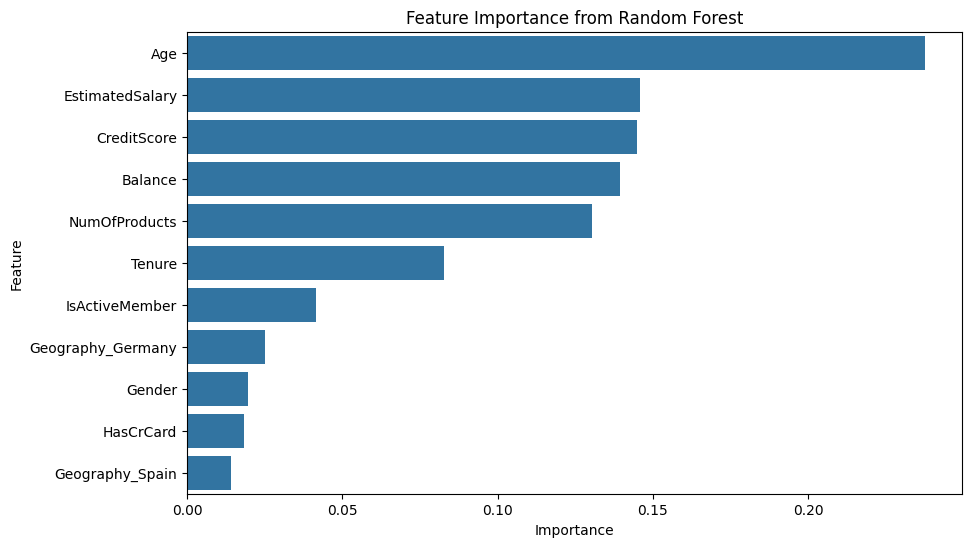

In [15]:
#visualization
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest')
plt.show()